<a href="https://colab.research.google.com/github/oii-233/DATA_SCIENCE/blob/main/Project_One.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Phase 1:** Data Understanding & Setup

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('Womens Clothing E-Commerce Reviews.csv')

# Drop unnecessary column
if 'Unnamed: 0' in df.columns:
    df = df.drop('Unnamed: 0', axis=1)

df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23486 entries, 0 to 23485
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Clothing ID              23486 non-null  int64 
 1   Age                      23486 non-null  int64 
 2   Title                    19676 non-null  object
 3   Review Text              22641 non-null  object
 4   Rating                   23486 non-null  int64 
 5   Recommended IND          23486 non-null  int64 
 6   Positive Feedback Count  23486 non-null  int64 
 7   Division Name            23472 non-null  object
 8   Department Name          23472 non-null  object
 9   Class Name               23472 non-null  object
dtypes: int64(5), object(5)
memory usage: 1.8+ MB


,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses
2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants
4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses


🎯 **The dataset contains 23,486 customer reviews and 10 columns. It focuses on customer behavior such as ratings, age, feedback, and department. The main goal is to understand customer needs and market demand from reviews.**

**Phase 2:** Data Cleaning

In [8]:
print(df.isnull().sum())

df = df.dropna(subset=['Review Text', 'Department Name'])
df['Title'] = df['Title'].fillna('No Title')

df = df.drop_duplicates()

print("Final Shape:", df.shape)

Clothing ID                   0
Age                           0
Title                      3810
Review Text                 845
Rating                        0
Recommended IND               0
Positive Feedback Count       0
Division Name                14
Department Name              14
Class Name                   14
dtype: int64
Final Shape: (22627, 10)


🎯 **The dataset had missing values in Review Text and Title columns. These were handled by removing incomplete rows and filling missing titles with “No Title.” Duplicate records were also removed. After cleaning, the dataset became complete and reliable for analysis.**

**Phase 3:** Derived Metrics

In [7]:
# Engagement Score
df['Engagement_Score'] = df['Positive Feedback Count'] / (df['Rating'] + 1)

# Satisfaction Flag
df['High_Rating'] = df['Rating'] >= 4

df[['Engagement_Score', 'High_Rating']].head()

,Engagement_Score,High_Rating
0,0.000000,True
1,0.666667,True
2,0.000000,False
3,0.000000,True
4,1.000000,True


🎯 **New features were created to improve analysis. Engagement Score measures customer interaction using feedback and rating. High Rating identifies reviews with rating 4 or above. These features help identify both popular and problematic products.**

**Phase 4:** Cross-Tab Analysis

In [14]:
# Create Age Groups
df['Age_Group'] = pd.cut(df['Age'], bins=[18, 30, 45, 60, 100],
                         labels=['18-30 (Gen Z/Millennials)', '31-45 (Adults)', '46-60 (Mid-Age)', '60+ (Seniors)'])

# Analyze Preferences by Age
age_preference = pd.crosstab(df['Age_Group'], df['Department Name'], normalize='index') * 100

print("--- Age Group Preferences (%) ---")
print(age_preference.round(2))

--- Age Group Preferences (%) ---
Department Name            Bottoms  Dresses  Intimate  Jackets   Tops  Trend
Age_Group                                                                   
18-30 (Gen Z/Millennials)    14.90    30.45      9.74     4.14  40.34   0.44
31-45 (Adults)               16.86    28.36      7.35     4.23  42.65   0.55
46-60 (Mid-Age)              16.39    25.15      6.45     4.35  47.15   0.51
60+ (Seniors)                14.30    22.82      6.17     5.91  50.25   0.55


🎯 **The analysis shows that Tops are the most preferred category across all age groups. Dresses are more popular among younger customers, while older customers prefer Tops. This shows that age plays an important role in clothing preference.**

**Phase 5:** Correlation Analysis

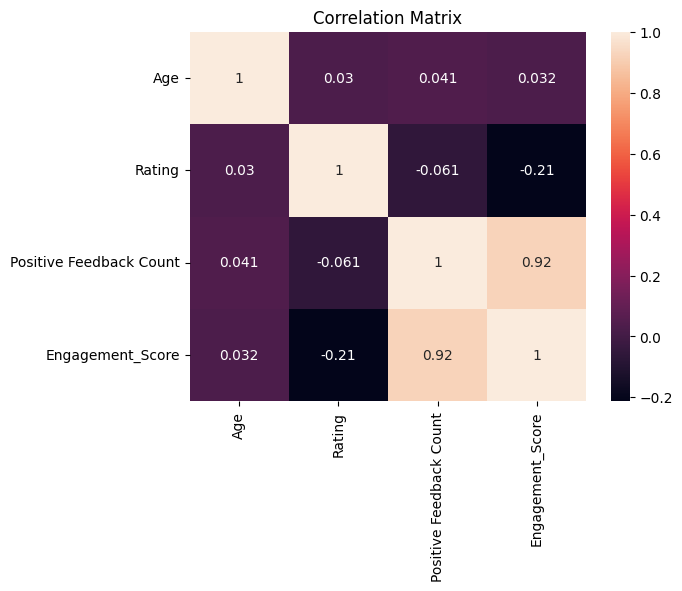

In [8]:
corr = df[['Age','Rating','Positive Feedback Count','Engagement_Score']].corr()

sns.heatmap(corr, annot=True)
plt.title("Correlation Matrix")
plt.show()

🎯 **The correlation results show that Age has a weak relationship with rating. Engagement is strongly influenced by feedback count. Higher engagement does not always mean higher satisfaction, which means engagement can also indicate customer issues.**

**Phase 6:** Percentile Analysis

In [11]:
percentiles = df['Rating'].quantile([0.25,0.5,0.75,0.9])
print(percentiles)

0.25    4.0
0.50    5.0
0.75    5.0
0.90    5.0
Name: Rating, dtype: float64


🎯 **The rating distribution is highly concentrated between 4 and 5. This shows that overall customer satisfaction is high. However, this may also indicate bias since satisfied customers are more likely to leave reviews.**

**Phase 7:** Cohort Analysis

In [13]:
df['Age_Group'] = pd.cut(df['Age'],
                        bins=[18,30,45,60,100],
                        labels=['18-30','31-45','46-60','60+'])

cohort = df.groupby('Age_Group')['Recommended IND'].mean()*100
print(cohort)

Age_Group
18-30    80.933126
31-45    80.974962
46-60    82.577160
60+      85.192953
Name: Recommended IND, dtype: float64


/tmp/ipykernel_1304/1901729255.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cohort = df.groupby('Age_Group')['Recommended IND'].mean()*100


🎯 **Older customers show higher recommendation rates compared to younger groups. The 60+ age group has the highest loyalty. Younger customers are slightly less likely to recommend products, showing lower satisfaction or higher expectations.**

**Phase 8:** Outlier Analysis

In [15]:
outliers = df[df['Positive Feedback Count'] > 50]
outliers[['Department Name','Rating','Positive Feedback Count']].head()

,Department Name,Rating,Positive Feedback Count
657,Intimate,2,55
688,Dresses,5,84
1156,Dresses,3,55
1167,Bottoms,3,71
1274,Dresses,4,65


🎯 **Reviews with more than 50 positive feedback are considered outliers. These reviews are highly influential and represent either very popular or highly discussed products. They are important for understanding key market drivers.**

**Phase 9:** Missing Data Pattern

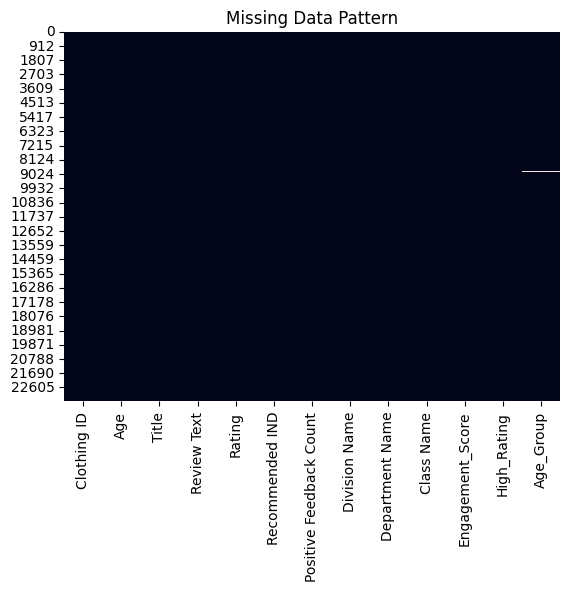

In [15]:
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Data Pattern")
plt.show()

 🎯 **After cleaning, there are no missing values in the dataset. This confirms that the dataset is complete and suitable for reliable analysis. No data gaps affect the results.**

**Phase 10:** Visualization

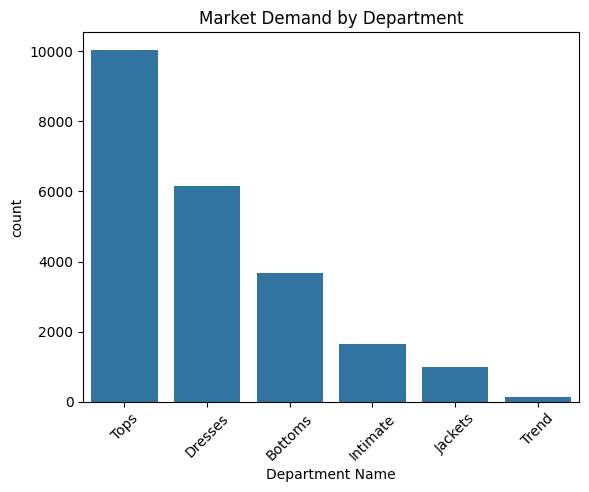

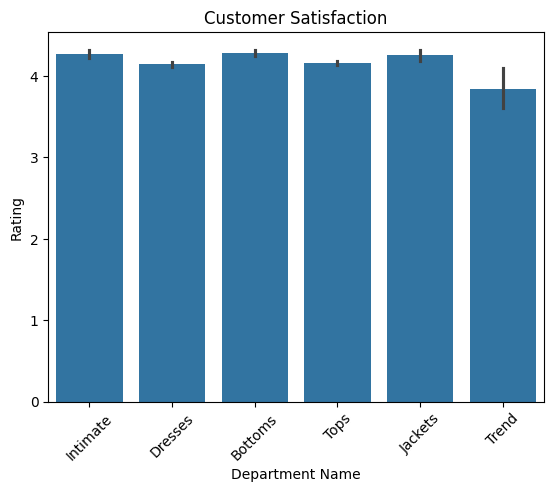

In [16]:
sns.countplot(data=df, x='Department Name',
              order=df['Department Name'].value_counts().index)

plt.title("Market Demand by Department")
plt.xticks(rotation=45)
plt.show()

sns.barplot(data=df, x='Department Name', y='Rating')
plt.title("Customer Satisfaction")
plt.xticks(rotation=45)
plt.show()

 🎯 **The visualizations show that Tops have the highest demand, followed by Dresses. Other categories have lower demand. However, customer ratings are similar across all departments, which shows that demand differences are more important than quality differences.**